# MPC vs PID Comparison — Boeing 747 Pitch Control

**Задача**: сравнить MPC (предобученный чекпоинт Hugging Face `TensorAeroSpace/mpc-b747-step-response`) и MATLAB-style PID на задаче отслеживания ступеньки угла тангажа Boeing 747. Запускайте ячейки через Poetry (`poetry run jupyter lab`/`poetry run python`).

## 1. Импорты и настройки

In [1]:
from pathlib import Path
import json
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import torch
from huggingface_hub import snapshot_download

from tensoraerospace.agent.pid import PID, MATLABTuneResult
from tensoraerospace.agent.mpc import (
    MPCAgent,
    MPCWeights,
    MPCConstraints,
    MPCTrackingExtraCostConfig,
    MPCStepResponseExtraCostConfig,
)
from tensoraerospace.signals.standart import unit_step
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

def pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = pick_device()
print(f"Device: {DEVICE}")


2026-01-08 10:37:06.343669: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-08 10:37:06.343707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-08 10:37:06.344632: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-08 10:37:06.349825: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-08 10:37:07.191184: W tensorflow/compiler/tf2

Device: cuda


## 2. Параметры симуляции

In [ ]:
# Параметры симуляции
DT = 0.1          # Шаг дискретизации (с)
TN = 20.0         # Длительность симуляции (с)

# Параметры тестового сценария (должны совпадать с другими ноутбуками сравнения)
AMPLITUDE_DEG = 1.0    # Амплитуда ступеньки (°)
STEP_TIME_SEC = 5.0    # Момент ступеньки (с)

# Генерация временной шкалы и референса
tp = generate_time_period(tn=TN, dt=DT)
t_sec = convert_tp_to_sec_tp(tp, dt=DT)
n_steps = len(tp)

# Референсный сигнал (ступенька)
step_time_idx = int(STEP_TIME_SEC / DT)
reference_rad = np.reshape(
    unit_step(degree=AMPLITUDE_DEG, tp=tp, time_step=step_time_idx, output_rad=True),
    [1, -1]
)
reference_deg = np.rad2deg(reference_rad[0])

print(f"📊 Параметры: TN={TN}с, DT={DT}с, шагов={n_steps}")
print(f"📊 Ступенька: {AMPLITUDE_DEG}° в момент t={STEP_TIME_SEC}с")


📊 Параметры: TN=20.0с, DT=0.1с, шагов=201
📊 Ступенька: 5.0° в момент t=5.0с


## 3. Вспомогательные функции (env, загрузка MPC, метрики)

In [3]:
def make_linear_env(
    *, dt: float, tn: float, amplitude_deg: float = 1.0, step_time_sec: float = 5.0,
    seed: int = 1, use_reward: bool = False
):
    """Создаёт LinearLongitudinalB747 с удобным интерфейсом."""
    tp = generate_time_period(tn=tn, dt=dt)
    step_idx = int(step_time_sec / dt)
    ref_rad = unit_step(tp=tp, degree=float(amplitude_deg), time_step=step_idx, output_rad=True)
    ref_rad = np.reshape(ref_rad, (1, -1))
    env = gym.make(
        'LinearLongitudinalB747-v0',
        number_time_steps=ref_rad.shape[1],
        use_reward=use_reward,
        initial_state=np.array([[0.0], [0.0], [0.0], [0.0]], dtype=np.float32),
        reference_signal=ref_rad,
        state_space=["u", "w", "q", "theta"],
        output_space=["u", "w", "q", "theta"],
        tracking_states=["theta"],
        dt=dt,
    )
    env.reset(seed=seed)
    t_sec = convert_tp_to_sec_tp(tp, dt=dt)
    return env, t_sec, ref_rad


def load_mpc_agent_from_hf(
    repo_id: str,
    *, env, device: str,
    cache_dir: Path = Path("data/hf"),
):
    """Загрузка MPCAgent из HF с обходом отсутствующих env-параметров.

    Важный адаптер: агент оптимизирует управление в радианах, а среда
    LinearLongitudinalB747 ожидает градусы. Добавляем action_to_env / action_from_env
    для корректного масштаба, иначе действия будут в ~57 раз меньше и
    MPC будет выглядеть «вялым».
    """
    cache_dir.mkdir(parents=True, exist_ok=True)
    local_dir = snapshot_download(
        repo_id=repo_id,
        local_dir=cache_dir / Path(repo_id).name,
        local_dir_use_symlinks=False,
    )
    repo_dir = Path(local_dir)

    with open(repo_dir / "config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    raw_params = dict(config["policy"]["params"])
    # model_class используется только для восстановления, не прокидываем в конструктор
    raw_params.pop("model_class", None)
    weights_cfg = raw_params.pop("weights", None)
    constraints_cfg = raw_params.pop("constraints", None)
    tracking_cfg = raw_params.pop("tracking_config", None)
    step_cfg = raw_params.pop("step_response_config", None)

    def _arr(x):
        return None if x is None else np.asarray(x, dtype=np.float32)

    mpc_kwargs = dict(raw_params)
    mpc_kwargs["tracking_type"] = raw_params.get("tracking_type", "step_response")

    if weights_cfg is not None:
        mpc_kwargs["weights"] = MPCWeights(
            Q_diag=_arr(weights_cfg.get("Q_diag")),
            R_diag=_arr(weights_cfg.get("R_diag")),
            S_diag=_arr(weights_cfg.get("S_diag")),
            terminal_weight=float(weights_cfg.get("terminal_weight", 1.0)),
        )
    if constraints_cfg is not None:
        mpc_kwargs["constraints"] = MPCConstraints(
            u_min=_arr(constraints_cfg.get("u_min")),
            u_max=_arr(constraints_cfg.get("u_max")),
            du_min=_arr(constraints_cfg.get("du_min")),
            du_max=_arr(constraints_cfg.get("du_max")),
        )
    if tracking_cfg is not None:
        mpc_kwargs["tracking_config"] = MPCTrackingExtraCostConfig(**tracking_cfg)
    if step_cfg is not None:
        mpc_kwargs["step_response_config"] = MPCStepResponseExtraCostConfig(**step_cfg)

    for key in ["state_dim", "action_dim", "horizon", "iters", "mpc_best_check_every", "memory_capacity", "seed"]:
        if key in mpc_kwargs:
            mpc_kwargs[key] = int(mpc_kwargs[key])
    for key in ["mpc_lr", "dynamics_lr", "grad_clip_norm"]:
        if key in mpc_kwargs and mpc_kwargs[key] is not None:
            mpc_kwargs[key] = float(mpc_kwargs[key])

    # Для CPU/MPS отключаем torch.compile
    mpc_kwargs["mpc_compile_dynamics"] = False
    mpc_kwargs["device"] = device
    mpc_kwargs["dtype"] = torch.float32

    # Адаптеры единиц: внутренняя оптимизация в рад, env ожидает градусы
    def _action_to_env(u_rad: np.ndarray) -> np.ndarray:
        return np.rad2deg(np.asarray(u_rad, dtype=np.float32)).reshape(-1)

    def _action_from_env(a_deg: np.ndarray) -> np.ndarray:
        return np.deg2rad(np.asarray(a_deg, dtype=np.float32)).reshape(-1)

    agent = MPCAgent(
        env=env,
        action_to_env=_action_to_env,
        action_from_env=_action_from_env,
        **mpc_kwargs,
    )

    model_state = torch.load(repo_dir / "dynamics_model.pth", map_location=device, weights_only=False)
    agent.model.load_state_dict(model_state)

    norms_path = repo_dir / "normalizers.npz"
    if norms_path.exists():
        data = np.load(norms_path)
        agent.x_scaler.mean = torch.as_tensor(data["x_mean"], device=device, dtype=agent.dtype)
        agent.x_scaler.std = torch.as_tensor(data["x_std"], device=device, dtype=agent.dtype)
        agent.u_scaler.mean = torch.as_tensor(data["u_mean"], device=device, dtype=agent.dtype)
        agent.u_scaler.std = torch.as_tensor(data["u_std"], device=device, dtype=agent.dtype)
        agent.y_scaler.mean = torch.as_tensor(data["y_mean"], device=device, dtype=agent.dtype)
        agent.y_scaler.std = torch.as_tensor(data["y_std"], device=device, dtype=agent.dtype)

    agent.model.eval()
    return agent, repo_dir


def compute_metrics(
    *, t_sec: np.ndarray, theta_deg: np.ndarray, theta_ref_deg: np.ndarray, u_deg: np.ndarray
) -> dict:
    """Вычисление метрик качества управления."""
    dt = float(t_sec[1] - t_sec[0])
    err = theta_ref_deg - theta_deg
    du = np.diff(u_deg, prepend=u_deg[:1]) / dt

    final_ref = theta_ref_deg[-1]
    if abs(final_ref) > 1e-6:
        tolerance = 0.05 * abs(final_ref)
        settled_mask = np.abs(err) <= tolerance
        settling_idx = len(t_sec) - 1
        for i in range(len(settled_mask) - 1, -1, -1):
            if not settled_mask[i]:
                settling_idx = i + 1
                break
        settling_time = t_sec[min(settling_idx, len(t_sec) - 1)]
    else:
        settling_time = float('nan')

    if abs(final_ref) > 1e-6:
        if final_ref > 0:
            overshoot_pct = max(0, (np.max(theta_deg) - final_ref) / final_ref * 100)
        else:
            overshoot_pct = max(0, (final_ref - np.min(theta_deg)) / abs(final_ref) * 100)
    else:
        overshoot_pct = float('nan')

    return {
        "n": int(theta_deg.size),
        "rmse_deg": float(np.sqrt(np.mean(err**2))),
        "iae_deg_s": float(np.sum(np.abs(err)) * dt),
        "ise_deg2_s": float(np.sum(err**2) * dt),
        "max_abs_err_deg": float(np.max(np.abs(err))),
        "settling_time_s": float(settling_time),
        "overshoot_pct": float(overshoot_pct),
        "u_rms_deg": float(np.sqrt(np.mean(u_deg**2))),
        "u_max_abs_deg": float(np.max(np.abs(u_deg))),
        "du_rms_deg_s": float(np.sqrt(np.mean(du**2))),
    }


def rollout_mpc(*, agent: MPCAgent, env, t_sec: np.ndarray, reference_rad: np.ndarray) -> dict:
    """Прогон эпизода с MPC-контроллером."""
    _obs, _info = env.reset()
    agent.env = env
    agent.reset()

    theta_deg = []
    theta_ref_deg = []
    u_deg = []

    horizon = int(getattr(agent, "_mpc_horizon", getattr(agent, "mpc", {}).horizon if hasattr(agent, "mpc") else 20))
    x_ref = np.zeros((horizon + 1, agent.state_dim), dtype=np.float32)

    for step in range(env.number_time_steps - 1):
        k = min(step, reference_rad.shape[1] - 1)
        theta_target = float(reference_rad[0, k])

        x_ref[:] = 0.0
        x_ref[:, 3] = theta_target
        rate_idx = getattr(getattr(agent, "step_response_config", None), "rate_idx", None)
        if rate_idx is not None and 0 <= rate_idx < agent.state_dim:
            x_ref[:, rate_idx] = 0.0

        state = np.asarray(env.unwrapped.model.xt, dtype=np.float32).reshape(-1)
        action = agent.select_action(state, x_ref=x_ref)
        _obs, _r, done, _tr, _info = env.step(action)

        theta_cur_rad = float(env.unwrapped.model.xt[3])
        theta_deg.append(np.rad2deg(theta_cur_rad))
        theta_ref_deg.append(np.rad2deg(theta_target))
        u_deg.append(float(np.asarray(action).reshape(-1)[0]))

        if done:
            break

    theta_deg = np.asarray(theta_deg)
    theta_ref_deg = np.asarray(theta_ref_deg)
    u_deg = np.asarray(u_deg)

    return {
        "theta_deg": theta_deg,
        "theta_ref_deg": theta_ref_deg,
        "u_deg": u_deg,
        "metrics": compute_metrics(
            t_sec=t_sec[: len(theta_deg)],
            theta_deg=theta_deg,
            theta_ref_deg=theta_ref_deg,
            u_deg=u_deg,
        ),
    }


def rollout_pid_linear(*, pid: PID, env, t_sec: np.ndarray, reference_rad: np.ndarray) -> dict:
    """Прогон эпизода с PID в линейной среде."""
    obs, _info = env.reset()
    pid.reset()

    theta_deg = []
    theta_ref_deg = []
    u_deg = []

    max_act = float(getattr(env.unwrapped, "max_action_value", 25.0))

    for step in range(env.number_time_steps - 1):
        theta_curr_deg = float(np.asarray(obs).reshape(-1)[3])
        theta_target_deg = float(np.rad2deg(reference_rad[0, min(step, reference_rad.shape[1] - 1)]))

        control = float(pid.select_action(theta_target_deg, theta_curr_deg))
        control = float(np.clip(control, -max_act, max_act))

        obs, _r, done, _tr, _info = env.step(np.array([control], dtype=np.float32))

        theta_deg.append(float(np.asarray(obs).reshape(-1)[3]))
        theta_ref_deg.append(theta_target_deg)
        u_deg.append(control)

        if done:
            break

    theta_deg = np.asarray(theta_deg)
    theta_ref_deg = np.asarray(theta_ref_deg)
    u_deg = np.asarray(u_deg)

    return {
        "theta_deg": theta_deg,
        "theta_ref_deg": theta_ref_deg,
        "u_deg": u_deg,
        "metrics": compute_metrics(
            t_sec=t_sec[: len(theta_deg)],
            theta_deg=theta_deg,
            theta_ref_deg=theta_ref_deg,
            u_deg=u_deg,
        ),
    }


## 4. Загрузка MPC из чекпоинта HF

In [4]:
mpc_env, t_eval, ref_eval = make_linear_env(
    dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, use_reward=False
)

mpc_agent, mpc_repo_dir = load_mpc_agent_from_hf(
    "TensorAeroSpace/mpc-b747-step-response", env=mpc_env, device=DEVICE
)

print("=" * 60)
print("MPC Agent Info")
print("=" * 60)
print(f"Checkpoint dir: {mpc_repo_dir}")
print(f"Device: {mpc_agent.device}")
print(f"Horizon: {getattr(mpc_agent, '_mpc_horizon', 'N/A')}")
print(f"Tracking type: {getattr(mpc_agent, 'tracking_type', 'tracking')}")


/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

MPC Agent Info
Checkpoint dir: /home/mr8bit/Projects/TensorAeroSpace/example/comparison/data/hf/mpc-b747-step-response
Device: cuda
Horizon: 20
Tracking type: step_response


## 5. MATLAB-Style тюнинг PID

In [5]:
env_for_tuning, _tune_t, _tune_ref = make_linear_env(
    dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, use_reward=False
)

pid_controller = PID(env=env_for_tuning, dt=DT)

tune_result = pid_controller.tune_matlab_style(
    track_state_idx=3,  # theta
    target_settling_time=3.0,
    target_overshoot=0.0,
    n_iterations=15,
    verbose=True,
    mode="step_response",
)

print(f" 📊 Результат тюнинга:")
print(f"   Kp = {pid_controller.kp:.4f}")
print(f"   Ki = {pid_controller.ki:.4f}")
print(f"   Kd = {pid_controller.kd:.4f}")
print(f"{tune_result}")



📊 MATLAB-Style PID Optimization (Step Response)
------------------------------------------------------------
   System dimension: 4 states
   Matrices: A=(4, 4), B=(4, 1), C=(4, 4), D=(4, 1)
   Simulation steps: 201, dt: 0.1s
   Mode: Step Response
   Target settling time: 3.0s
   Target overshoot: 0.0%
   DC Gain: -0.9098

   🔄 Running optimization (15 iterations)...


/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


   Optimization:   0%|          | 0/15 [00:00<?]

/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")



   ✅ Optimization completed!
   Kp=-24.1292, Ki=-0.6849, Kd=-7.3157
   [Primary step] Settling time: 6.10s
   [Primary step] Overshoot: 0.00%
   [Primary step] Static error: -0.0051
   [Secondary sine] RMSE: 0.7520
 📊 Результат тюнинга:
   Kp = -24.1292
   Ki = -0.6849
   Kd = -7.3157
MATLABTuneResult(Kp=-24.1292, Ki=-0.6849, Kd=-7.3157, settling_time=6.10s, overshoot=0.00%)


## 6. Сравнение MPC vs PID на одинаковом сценарии

In [6]:
# Отдельные окружения для чистых прогонов
pid_env, t_test, ref_test = make_linear_env(
    dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, use_reward=False
)
mpc_env_eval, _, _ = make_linear_env(
    dt=DT, tn=TN, amplitude_deg=AMPLITUDE_DEG, step_time_sec=STEP_TIME_SEC, use_reward=False
)

pid_out = rollout_pid_linear(pid=pid_controller, env=pid_env, t_sec=t_test, reference_rad=ref_test)
mpc_out = rollout_mpc(agent=mpc_agent, env=mpc_env_eval, t_sec=t_test, reference_rad=ref_test)

print("=" * 60)
print("📊 Metrics Comparison (lower = better)")
print("=" * 60)

metrics_list = [
    ("RMSE (°)", "rmse_deg", "lower"),
    ("IAE (°·s)", "iae_deg_s", "lower"),
    ("ISE (°²·s)", "ise_deg2_s", "lower"),
    ("Max Error (°)", "max_abs_err_deg", "lower"),
    ("Settling Time (s)", "settling_time_s", "lower"),
    ("Overshoot (%)", "overshoot_pct", "lower"),
    ("Control RMS (°)", "u_rms_deg", "lower"),
    ("Control Max (°)", "u_max_abs_deg", "lower"),
    ("Control Rate RMS (°/s)", "du_rms_deg_s", "lower"),
]

comparison_data = []
mpc_wins = 0
pid_wins = 0

for name, key, better in metrics_list:
    pid_val = pid_out["metrics"][key]
    mpc_val = mpc_out["metrics"][key]

    if better == "lower":
        winner = "MPC" if mpc_val < pid_val else ("PID" if pid_val < mpc_val else "TIE")
    else:
        winner = "MPC" if mpc_val > pid_val else ("PID" if pid_val > mpc_val else "TIE")

    if winner == "MPC":
        mpc_wins += 1
    elif winner == "PID":
        pid_wins += 1

    diff_pct = (mpc_val - pid_val) / abs(pid_val) * 100 if abs(pid_val) > 1e-9 else 0.0

    comparison_data.append({
        "Metric": name,
        "PID": f"{pid_val:.4f}",
        "MPC": f"{mpc_val:.4f}",
        "Δ (%)": f"{diff_pct:+.1f}%",
        "Winner": f"✅ {winner}",
    })

LAMBDA_CONTROL = 0.1
pid_composite = pid_out["metrics"]["rmse_deg"] + LAMBDA_CONTROL * pid_out["metrics"]["u_rms_deg"]
mpc_composite = mpc_out["metrics"]["rmse_deg"] + LAMBDA_CONTROL * mpc_out["metrics"]["u_rms_deg"]

composite_winner = "MPC" if mpc_composite < pid_composite else "PID"
comparison_data.append({
    "Metric": "━━━━━━━━━━━━━━━━━━━━━━",
    "PID": "━━━━━━",
    "MPC": "━━━━━━",
    "Δ (%)": "━━━━━━",
    "Winner": "━━━━━━━━",
})
comparison_data.append({
    "Metric": f"Composite (RMSE+{LAMBDA_CONTROL}×U_RMS)",
    "PID": f"{pid_composite:.4f}",
    "MPC": f"{mpc_composite:.4f}",
    "Δ (%)": f"{(mpc_composite - pid_composite) / pid_composite * 100:+.1f}%",
    "Winner": f"🏆 {composite_winner}",
})

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print(f"🔧 PID параметры: Kp={pid_controller.kp:.4f}, Ki={pid_controller.ki:.4f}, Kd={pid_controller.kd:.4f}")
print(f"📊 Счёт по метрикам: MPC={mpc_wins}, PID={pid_wins}")


/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.number_time_steps to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.number_time_steps` for environment variables or `env.get_wrapper_attr('number_time_steps')` that will search the reminding wrappers.
  logger.warn(
/tmp/ipykernel_51094/2686113604.py:195: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  theta_cur_rad = float(env.unwrapped.model.xt[3])


📊 Metrics Comparison (lower = better)
                    Metric     PID     MPC  Δ (%)   Winner
                  RMSE (°)  0.5973  0.6798 +13.8%    ✅ PID
                 IAE (°·s)  2.3909  2.7142 +13.5%    ✅ PID
                ISE (°²·s)  7.0988  9.1951 +29.5%    ✅ PID
             Max Error (°)  4.8576  4.9430  +1.8%    ✅ PID
         Settling Time (s)  6.1000  5.9000  -3.3%    ✅ MPC
             Overshoot (%)  0.0000  2.7413  +0.0%    ✅ PID
           Control RMS (°)  4.7733  3.0957 -35.1%    ✅ MPC
           Control Max (°) 25.0000 25.0000  -0.0%    ✅ MPC
    Control Rate RMS (°/s) 35.5123 16.0566 -54.8%    ✅ MPC
    ━━━━━━━━━━━━━━━━━━━━━━  ━━━━━━  ━━━━━━ ━━━━━━ ━━━━━━━━
Composite (RMSE+0.1×U_RMS)  1.0746  0.9893  -7.9%    🏆 MPC
🔧 PID параметры: Kp=-24.1292, Ki=-0.6849, Kd=-7.3157
📊 Счёт по метрикам: MPC=4, PID=5


## 7. Визуализация

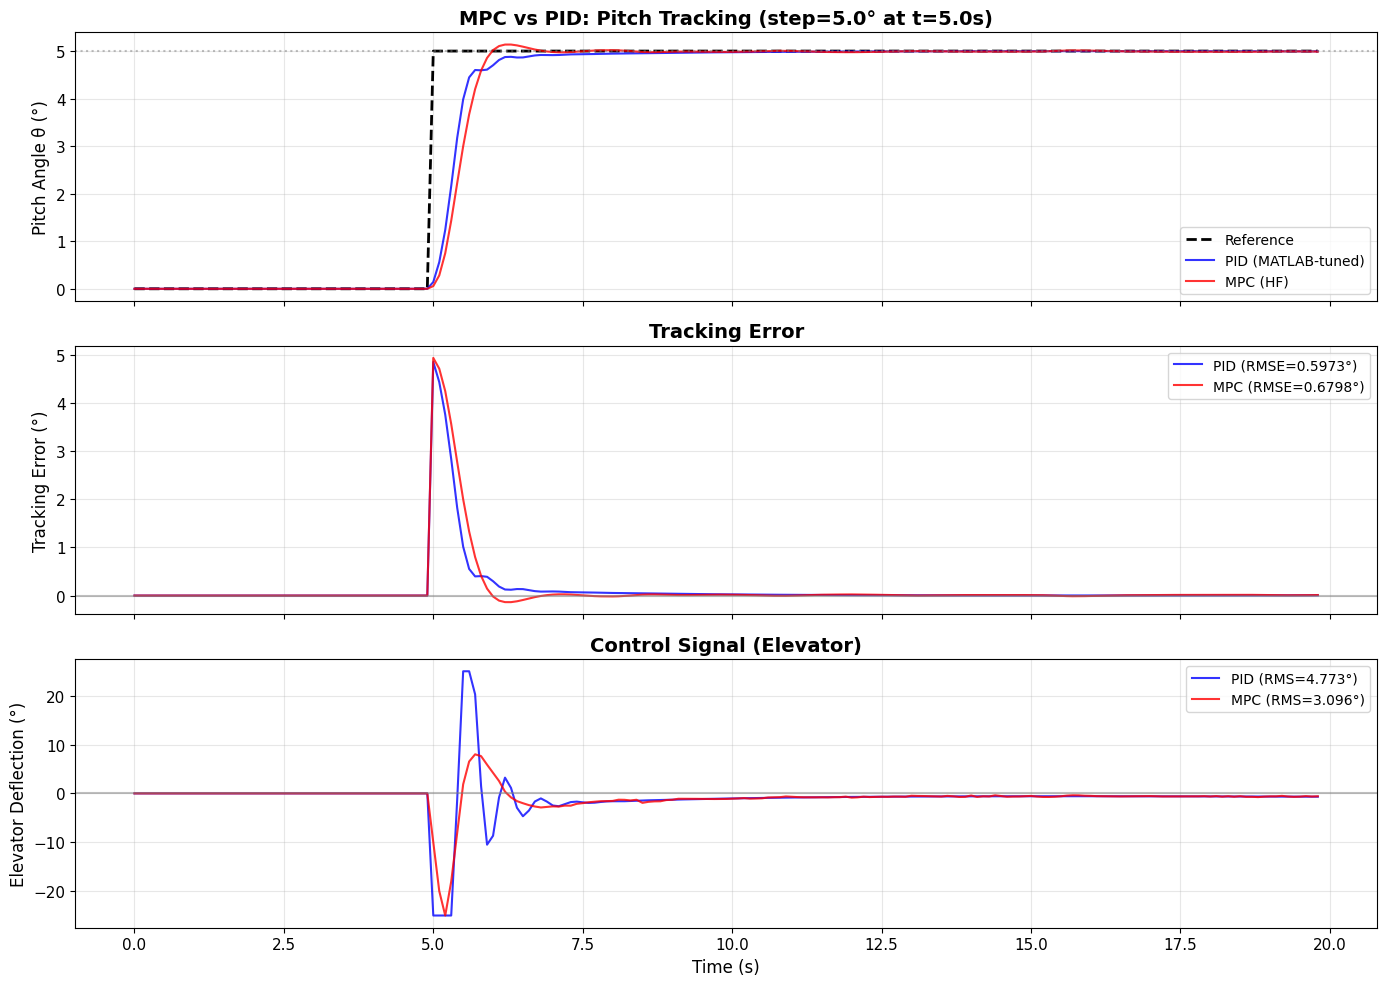

📁 Plot saved to: mpc_vs_pid_comparison.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

t_plot = t_test[: pid_out["theta_deg"].size]

ax = axes[0]
ax.plot(t_plot, pid_out["theta_ref_deg"], "k--", linewidth=2, label="Reference")
ax.plot(t_plot, pid_out["theta_deg"], "b-", linewidth=1.5, alpha=0.8, label="PID (MATLAB-tuned)")
ax.plot(t_plot, mpc_out["theta_deg"], "r-", linewidth=1.5, alpha=0.8, label="MPC (HF)")
ax.set_ylabel("Pitch Angle θ (°)", fontsize=12)
ax.set_title(f"MPC vs PID: Pitch Tracking (step={AMPLITUDE_DEG}° at t={STEP_TIME_SEC}s)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=AMPLITUDE_DEG, color="gray", linestyle=":", alpha=0.5)

ax = axes[1]
pid_err = pid_out["theta_ref_deg"] - pid_out["theta_deg"]
mpc_err = mpc_out["theta_ref_deg"] - mpc_out["theta_deg"]
ax.plot(t_plot, pid_err, "b-", linewidth=1.5, alpha=0.8, label=f"PID (RMSE={pid_out['metrics']['rmse_deg']:.4f}°)")
ax.plot(t_plot, mpc_err, "r-", linewidth=1.5, alpha=0.8, label=f"MPC (RMSE={mpc_out['metrics']['rmse_deg']:.4f}°)")
ax.set_ylabel("Tracking Error (°)", fontsize=12)
ax.set_title("Tracking Error", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)

ax = axes[2]
ax.plot(t_plot, pid_out["u_deg"], "b-", linewidth=1.5, alpha=0.8, label=f"PID (RMS={pid_out['metrics']['u_rms_deg']:.3f}°)")
ax.plot(t_plot, mpc_out["u_deg"], "r-", linewidth=1.5, alpha=0.8, label=f"MPC (RMS={mpc_out['metrics']['u_rms_deg']:.3f}°)")
ax.set_ylabel("Elevator Deflection (°)", fontsize=12)
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_title("Control Signal (Elevator)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)

plt.tight_layout()
plt.savefig("mpc_vs_pid_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("📁 Plot saved to: mpc_vs_pid_comparison.png")


## 8. Итоговое сравнение

In [10]:
print("=" * 70)
print("🏆 ИТОГОВОЕ СРАВНЕНИЕ: MPC vs PID")
print(f"   Сценарий: ступенька {AMPLITUDE_DEG}° в момент t={STEP_TIME_SEC}с")
print("=" * 70)

mpc_wins = 0
pid_wins = 0
for name, key, better in metrics_list:
    pid_val = pid_out["metrics"][key]
    mpc_val = mpc_out["metrics"][key]
    if better == "lower":
        if mpc_val < pid_val:
            mpc_wins += 1
        elif pid_val < mpc_val:
            pid_wins += 1
    else:
        if mpc_val > pid_val:
            mpc_wins += 1
        elif pid_val > mpc_val:
            pid_wins += 1

print(f"📊 Счёт по отдельным метрикам:")
print(f"   MPC: {mpc_wins} побед")
print(f"   PID: {pid_wins} побед")

LAMBDA = 0.1
pid_composite = pid_out["metrics"]["rmse_deg"] + LAMBDA * pid_out["metrics"]["u_rms_deg"]
mpc_composite = mpc_out["metrics"]["rmse_deg"] + LAMBDA * mpc_out["metrics"]["u_rms_deg"]

print(f"📈 Композитная метрика (RMSE + {LAMBDA}×Control_RMS):")
print(f"   PID: {pid_composite:.4f}")
print(f"   MPC: {mpc_composite:.4f}")

if mpc_composite < pid_composite:
    print(f"   Разница: {(pid_composite - mpc_composite) / pid_composite * 100:.1f}% в пользу MPC")
else:
    print(f"   Разница: {(mpc_composite - pid_composite) / mpc_composite * 100:.1f}% в пользу PID")

print(f"📋 Детальное сравнение:")
print(f"   • Settling Time: MPC={mpc_out['metrics']['settling_time_s']:.2f}с vs PID={pid_out['metrics']['settling_time_s']:.2f}с")
print(f"   • RMSE: MPC={mpc_out['metrics']['rmse_deg']:.4f}° vs PID={pid_out['metrics']['rmse_deg']:.4f}°")
print(f"   • Control RMS: MPC={mpc_out['metrics']['u_rms_deg']:.3f}° vs PID={pid_out['metrics']['u_rms_deg']:.3f}°")
print(f"   • Control Max: MPC={mpc_out['metrics']['u_max_abs_deg']:.3f}° vs PID={pid_out['metrics']['u_max_abs_deg']:.3f}°")
print(f"   • Overshoot: MPC={mpc_out['metrics']['overshoot_pct']:.2f}% vs PID={pid_out['metrics']['overshoot_pct']:.2f}%")

winner = "MPC" if mpc_composite < pid_composite else "PID"
print("" + "=" * 70)
print(f"🏆 ПОБЕДИТЕЛЬ ПО КОМПОЗИТНОЙ МЕТРИКЕ: {winner}")
print("=" * 70)

🏆 ИТОГОВОЕ СРАВНЕНИЕ: MPC vs PID
   Сценарий: ступенька 5.0° в момент t=5.0с
📊 Счёт по отдельным метрикам:
   MPC: 4 побед
   PID: 5 побед
📈 Композитная метрика (RMSE + 0.1×Control_RMS):
   PID: 1.0746
   MPC: 0.9893
   Разница: 7.9% в пользу MPC
📋 Детальное сравнение:
   • Settling Time: MPC=5.90с vs PID=6.10с
   • RMSE: MPC=0.6798° vs PID=0.5973°
   • Control RMS: MPC=3.096° vs PID=4.773°
   • Control Max: MPC=25.000° vs PID=25.000°
   • Overshoot: MPC=2.74% vs PID=0.00%
🏆 ПОБЕДИТЕЛЬ ПО КОМПОЗИТНОЙ МЕТРИКЕ: MPC


## 9. Визуализация ключевых метрик

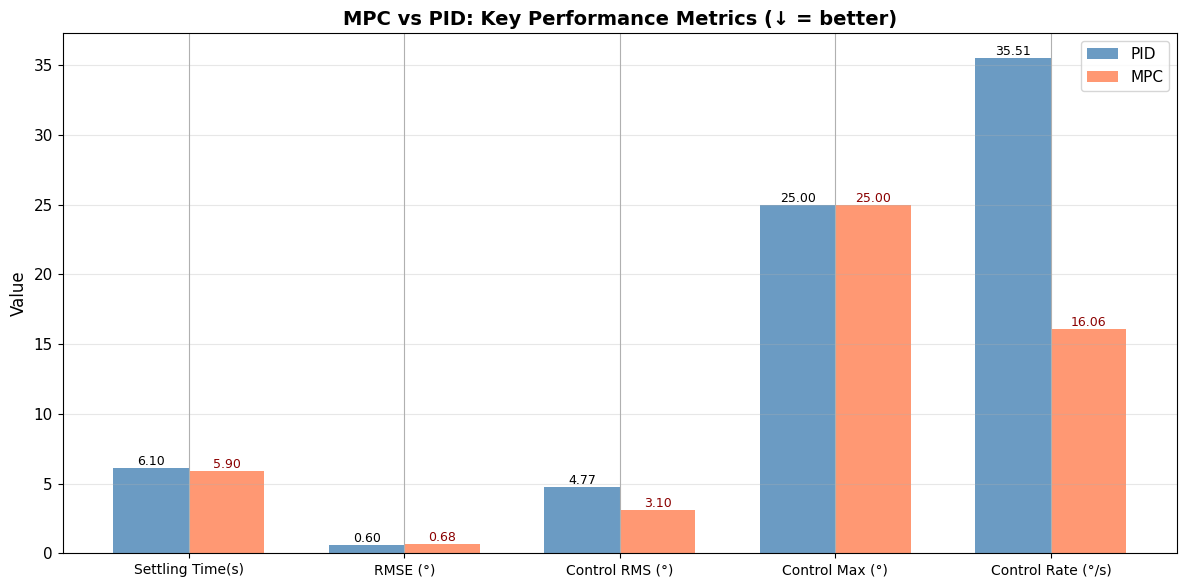

📁 Plot saved to: mpc_vs_pid_metrics.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_show = [
    ("Settling Time(s)", pid_out["metrics"]["settling_time_s"], mpc_out["metrics"]["settling_time_s"]),
    ("RMSE (°)", pid_out["metrics"]["rmse_deg"], mpc_out["metrics"]["rmse_deg"]),
    ("Control RMS (°)", pid_out["metrics"]["u_rms_deg"], mpc_out["metrics"]["u_rms_deg"]),
    ("Control Max (°)", pid_out["metrics"]["u_max_abs_deg"], mpc_out["metrics"]["u_max_abs_deg"]),
    ("Control Rate (°/s)", pid_out["metrics"]["du_rms_deg_s"], mpc_out["metrics"]["du_rms_deg_s"]),
]

names = [m[0] for m in metrics_to_show]
pid_vals = [m[1] for m in metrics_to_show]
mpc_vals = [m[2] for m in metrics_to_show]

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, pid_vals, width, label="PID", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, mpc_vals, width, label="MPC", color="coral", alpha=0.8)

ax.set_ylabel("Value", fontsize=12)
ax.set_title("MPC vs PID: Key Performance Metrics (↓ = better)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars1, pid_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}',
            ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, mpc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.2f}',
            ha='center', va='bottom', fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig("mpc_vs_pid_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print("📁 Plot saved to: mpc_vs_pid_metrics.png")
